# KernelSynth: exhaustive bank and sampled-composition AR coverage

This experiment is exclusively about the KernelSynth prior used by Chronos. It evaluates every one
of the 33 entries in the official kernel bank and every composite function sampled below. Each fixed
function generates 16 independent training trajectories and 16 new test trajectories of length
1,024. No trajectory used for fitting is reused for evaluation.

“All functions” here has a precise finite meaning: all 33 official bank entries plus all 20 seeded
compositions generated by this notebook. It cannot mean all possible KernelSynth expressions,
because sampling up to five kernels with replacement and binary operators defines a much larger
combinatorial space.

Official provenance: `amazon-science/chronos-forecasting`, commit
`10afa9ebe016e514f9d7dc1aa873f66af57e116b`, `scripts/kernel-synth.py`.

In [1]:
from __future__ import annotations

import json
import platform
import subprocess
import sys
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.signal import periodogram
from scipy.stats import wasserstein_distance
from sklearn.gaussian_process.kernels import (
    ConstantKernel, DotProduct, ExpSineSquared, RBF, RationalQuadratic, WhiteKernel
)

GLOBAL_SEED = 20260930
LENGTH = 1024
N_TRAIN = 16
N_TEST = 16
RIDGE = 1e-5
MAX_ACF_LAG = 64
THRESHOLDS = {
    "acf_mae": 0.10,
    "psd_jsd": 0.10,
    "abs_log_variance_ratio": 0.25,
    "standardized_wasserstein": 0.25,
}
time = np.linspace(0.0, 1.0, LENGTH)[:, None]

ORDERS = [1, 2, 4, 8, 16, 32, 64, 128, 256]
PERIODS = [
    24, 48, 96, 24 * 7, 48 * 7, 96 * 7, 7, 14, 30, 60, 365, 365 * 2,
    4, 26, 52, 4, 6, 12, 4, 4 * 10, 10,
]
KERNEL_BANK = []
for index, period in enumerate(PERIODS, start=1):
    KERNEL_BANK.append({
        "id": f"periodic_{index:02d}_p{period}",
        "formula": f"ExpSineSquared(length_scale=1, periodicity={period}/1024)",
        "family": "periodic",
        "kernel": ExpSineSquared(length_scale=1.0, periodicity=period / LENGTH),
    })
for sigma in [0.0, 1.0, 10.0]:
    KERNEL_BANK.append({"id": f"linear_sigma{sigma:g}", "formula": f"DotProduct(sigma_0={sigma:g})",
                        "family": "linear", "kernel": DotProduct(sigma_0=sigma)})
for scale in [0.1, 1.0, 10.0]:
    KERNEL_BANK.append({"id": f"rbf_scale{scale:g}", "formula": f"RBF(length_scale={scale:g})",
                        "family": "rbf", "kernel": RBF(length_scale=scale)})
for alpha in [0.1, 1.0, 10.0]:
    KERNEL_BANK.append({"id": f"rq_alpha{alpha:g}",
                        "formula": f"RationalQuadratic(length_scale=1, alpha={alpha:g})",
                        "family": "rational_quadratic",
                        "kernel": RationalQuadratic(length_scale=1.0, alpha=alpha)})
for level in [0.1, 1.0]:
    KERNEL_BANK.append({"id": f"white_level{level:g}", "formula": f"WhiteKernel(noise_level={level:g})",
                        "family": "white", "kernel": WhiteKernel(noise_level=level)})
KERNEL_BANK.append({"id": "constant_1", "formula": "ConstantKernel(constant_value=1)",
                    "family": "constant", "kernel": ConstantKernel(constant_value=1.0)})
assert len(KERNEL_BANK) == 33

def covariance(kernel):
    matrix = np.asarray(kernel(time), dtype=float)
    return (matrix + matrix.T) / 2


def stable_factor(matrix):
    scale = max(float(np.mean(np.diag(matrix))), 1.0)
    identity = np.eye(len(matrix))
    for exponent in range(-10, -3):
        try:
            return np.linalg.cholesky(matrix + (10.0**exponent) * scale * identity)
        except np.linalg.LinAlgError:
            pass
    values, vectors = np.linalg.eigh((matrix + matrix.T) / 2)
    return vectors @ np.diag(np.sqrt(np.maximum(values, 1e-8 * scale)))


def draw_from_factor(factor, count, local_rng):
    return local_rng.standard_normal((count, factor.shape[0])) @ factor.T


def standardize_train_test(train, test):
    mean = float(np.mean(train))
    scale = float(np.std(train) + 1e-12)
    return (train - mean) / scale, (test - mean) / scale, mean, scale


def lagged_design(series, order):
    xs, ys = [], []
    for trajectory in series:
        windows = np.lib.stride_tricks.sliding_window_view(trajectory, order + 1)
        xs.append(windows[:, :-1][:, ::-1])
        ys.append(windows[:, -1])
    return np.vstack(xs), np.concatenate(ys)


@dataclass
class ARFit:
    intercept: float
    coefficients: np.ndarray
    innovation_variance: float


def fit_ar(series, order):
    x, y = lagged_design(series, order)
    design = np.column_stack([np.ones(len(x)), x])
    penalty = RIDGE * np.eye(design.shape[1]); penalty[0, 0] = 0.0
    beta = np.linalg.solve(design.T @ design + penalty, design.T @ y)
    residual = y - design @ beta
    return ARFit(float(beta[0]), beta[1:], float(np.mean(residual**2) + 1e-10))


def ar_predictions(fit, series):
    x, _ = lagged_design(series, len(fit.coefficients))
    return fit.intercept + x @ fit.coefficients


def simulate_ar(fit, initials, length, local_rng):
    order = len(fit.coefficients)
    output = np.zeros((len(initials), length)); output[:, :order] = initials[:, :order]
    noise = local_rng.normal(scale=np.sqrt(fit.innovation_variance), size=output.shape)
    for t in range(order, length):
        output[:, t] = fit.intercept + output[:, t-order:t][:, ::-1] @ fit.coefficients + noise[:, t]
        output[:, t] = np.clip(output[:, t], -1e8, 1e8)
    return output


def acf_vector(values, max_lag):
    centered = values - values.mean(axis=1, keepdims=True)
    denom = np.mean(centered**2, axis=1) + 1e-12
    return np.array([np.mean(np.mean(centered[:, :-lag] * centered[:, lag:], axis=1) / denom)
                     for lag in range(1, max_lag + 1)])


def psd_distribution(values):
    _, power = periodogram(values, axis=1, detrend=False)
    power = np.mean(power, axis=0) + 1e-12
    return power / power.sum()


def js_divergence(p, q):
    middle = 0.5 * (p + q)
    return float(0.5 * np.sum(p * np.log(p / middle)) + 0.5 * np.sum(q * np.log(q / middle)))


def distribution_metrics(reference, generated, start):
    ref, gen = reference[:, start:], generated[:, start:]
    ref_scale = float(np.std(ref) + 1e-12)
    return {
        "acf_mae": float(np.mean(np.abs(acf_vector(ref, MAX_ACF_LAG) - acf_vector(gen, MAX_ACF_LAG)))),
        "psd_jsd": js_divergence(psd_distribution(ref), psd_distribution(gen)),
        "abs_log_variance_ratio": float(abs(np.log((np.var(gen) + 1e-12) / (np.var(ref) + 1e-12)))),
        "standardized_wasserstein": float(wasserstein_distance(ref.ravel(), gen.ravel()) / ref_scale),
    }


def passes(metrics):
    return all(np.isfinite(metrics[key]) and metrics[key] <= value for key, value in THRESHOLDS.items())


def violation_score(row, include_cross=False):
    score = sum(max(float(row[key]) / value - 1.0, 0.0) for key, value in THRESHOLDS.items())
    if include_cross:
        score += max(float(row["cross_corr_frobenius"]) / 0.10 - 1.0, 0.0)
    return score


## Generate the complete finite test set

The base set preserves duplicate bank positions because they are distinct sampling mass in the
official prior. Twenty deterministic composite expressions use two to five bank entries and both
addition and multiplication. Covariance addition and elementwise multiplication are exactly the
corresponding GP-kernel composition operations. Every formula is retained.

In [2]:
base_covariances = [covariance(item["kernel"]) for item in KERNEL_BANK]
FUNCTIONS = [
    {"id": item["id"], "formula": item["formula"], "category": "base",
     "family": item["family"], "covariance": base_covariances[index]}
    for index, item in enumerate(KERNEL_BANK)
]

composition_rng = np.random.default_rng(GLOBAL_SEED + 10_000)
for number in range(20):
    count = 2 + number % 4
    indices = composition_rng.integers(0, len(KERNEL_BANK), size=count)
    operators = composition_rng.choice(["+", "*"], size=count - 1)
    matrix = base_covariances[int(indices[0])].copy()
    formula = f"({KERNEL_BANK[int(indices[0])]['formula']})"
    for operator, index in zip(operators, indices[1:]):
        item = KERNEL_BANK[int(index)]
        matrix = matrix + base_covariances[int(index)] if operator == "+" else matrix * base_covariances[int(index)]
        formula = f"({formula} {operator} ({item['formula']}))"
    FUNCTIONS.append({"id": f"composite_{number + 1:02d}", "formula": formula,
                      "category": "composite", "family": "composite", "covariance": matrix})

assert len(FUNCTIONS) == 53
display(pd.DataFrame([{k: f[k] for k in ["id", "category", "family", "formula"]} for f in FUNCTIONS]))

,id,category,family,formula
0,periodic_01_p24,base,periodic,"ExpSineSquared(length_scale=1, periodicity=24/..."
1,periodic_02_p48,base,periodic,"ExpSineSquared(length_scale=1, periodicity=48/..."
2,periodic_03_p96,base,periodic,"ExpSineSquared(length_scale=1, periodicity=96/..."
3,periodic_04_p168,base,periodic,"ExpSineSquared(length_scale=1, periodicity=168..."
4,periodic_05_p336,base,periodic,"ExpSineSquared(length_scale=1, periodicity=336..."
5,periodic_06_p672,base,periodic,"ExpSineSquared(length_scale=1, periodicity=672..."
6,periodic_07_p7,base,periodic,"ExpSineSquared(length_scale=1, periodicity=7/1..."
7,periodic_08_p14,base,periodic,"ExpSineSquared(length_scale=1, periodicity=14/..."
8,periodic_09_p30,base,periodic,"ExpSineSquared(length_scale=1, periodicity=30/..."
9,periodic_10_p60,base,periodic,"ExpSineSquared(length_scale=1, periodicity=60/..."


## Fit and evaluate every generated function

Coverage is a joint empirical criterion: ACF MAE ≤ 0.10, PSD Jensen–Shannon divergence ≤ 0.10,
absolute log variance ratio ≤ 0.25, and standardized marginal Wasserstein distance ≤ 0.25.
Forecast NMSE is reported but is not a coverage gate: irreducible white noise should have NMSE near
one while still being correctly represented as a stochastic process.

In [3]:
rows = []
for function_index, function in enumerate(FUNCTIONS):
    factor = stable_factor(function["covariance"])
    local_rng = np.random.default_rng(GLOBAL_SEED + 100_000 + function_index)
    raw_train = draw_from_factor(factor, N_TRAIN, local_rng)
    raw_test = draw_from_factor(factor, N_TEST, local_rng)
    train, test, _, _ = standardize_train_test(raw_train, raw_test)
    for order in ORDERS:
        fit = fit_ar(train, order)
        generated = simulate_ar(fit, test[:, :order], LENGTH,
                                np.random.default_rng(GLOBAL_SEED + 1_000_000 + 1000 * function_index + order))
        _, target = lagged_design(test, order)
        forecast_nmse = float(np.mean((target - ar_predictions(fit, test))**2) / (np.var(target) + 1e-12))
        metrics = distribution_metrics(test, generated, order)
        rows.append({"function": function["id"], "category": function["category"],
                     "family": function["family"], "formula": function["formula"], "order": order,
                     "forecast_nmse": forecast_nmse, **metrics, "well_covered": passes(metrics)})

results = pd.DataFrame(rows)
results["violation_score"] = results.apply(violation_score, axis=1)
best = (results.sort_values(["function", "violation_score", "order"])
        .groupby("function", as_index=False).first())
best["well_covered_any_order"] = results.groupby("function")["well_covered"].any().reindex(best.function).values
coverage_curve = results.groupby("order")["well_covered"].mean()
display(best[["function", "category", "family", "order", "well_covered_any_order",
              "acf_mae", "psd_jsd", "abs_log_variance_ratio", "standardized_wasserstein",
              "forecast_nmse"]].round(4))

,function,category,family,order,well_covered_any_order,acf_mae,psd_jsd,abs_log_variance_ratio,standardized_wasserstein,forecast_nmse
0,composite_01,composite,composite,4,True,0.0759,0.0243,0.0802,0.0889,0.0000
1,composite_02,composite,composite,256,True,0.0007,0.0000,0.0060,0.0029,0.0000
2,composite_03,composite,composite,32,False,0.0942,0.1368,0.1365,0.1037,0.0000
3,composite_04,composite,composite,256,True,0.0129,0.0006,0.0073,0.0239,0.0000
4,composite_05,composite,composite,16,True,0.0040,0.0000,0.0024,0.0049,0.0000
5,composite_06,composite,composite,128,False,0.0333,0.0360,0.3386,0.2063,0.0000
6,composite_07,composite,composite,64,True,0.0235,0.0764,0.0258,0.0883,0.0371
7,composite_08,composite,composite,64,True,0.0671,0.0758,0.0644,0.1956,0.0200
8,composite_09,composite,composite,32,True,0.0718,0.0626,0.1736,0.1731,0.0000
9,composite_10,composite,composite,32,True,0.0404,0.0018,0.0792,0.0481,0.0000


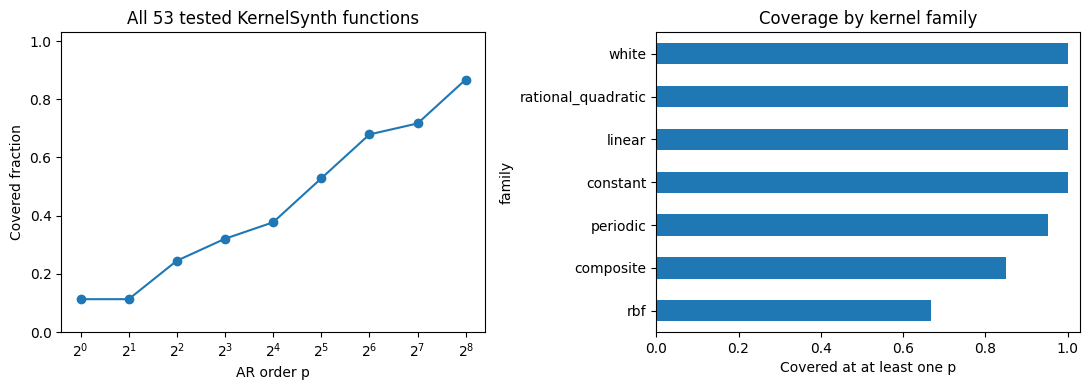

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(coverage_curve.index, coverage_curve.values, marker="o")
axes[0].set_xscale("log", base=2); axes[0].set_ylim(0, 1.03)
axes[0].set_xlabel("AR order p"); axes[0].set_ylabel("Covered fraction")
axes[0].set_title("All 53 tested KernelSynth functions")
family_coverage = best.groupby("family")["well_covered_any_order"].mean().sort_values()
family_coverage.plot.barh(ax=axes[1]); axes[1].set_xlim(0, 1.03)
axes[1].set_xlabel("Covered at at least one p"); axes[1].set_title("Coverage by kernel family")
fig.tight_layout(); plt.show()

## Final classification of every KernelSynth function

In [5]:
covered_functions = best.loc[best.well_covered_any_order, "function"].tolist()
not_covered_functions = best.loc[~best.well_covered_any_order, "function"].tolist()
print(f"WELL COVERED ({len(covered_functions)}/{len(best)}):")
print("\n".join(f"  - {name}" for name in covered_functions) or "  (none)")
print(f"\nNOT WELL COVERED ({len(not_covered_functions)}/{len(best)}):")
print("\n".join(f"  - {name}" for name in not_covered_functions) or "  (none)")
display(best[["function", "formula", "order", "well_covered_any_order"]])

WELL COVERED (48/53):
  - composite_01
  - composite_02
  - composite_04
  - composite_05
  - composite_07
  - composite_08
  - composite_09
  - composite_10
  - composite_11
  - composite_12
  - composite_14
  - composite_15
  - composite_16
  - composite_17
  - composite_18
  - composite_19
  - composite_20
  - constant_1
  - linear_sigma0
  - linear_sigma1
  - linear_sigma10
  - periodic_01_p24
  - periodic_02_p48
  - periodic_03_p96
  - periodic_04_p168
  - periodic_05_p336
  - periodic_07_p7
  - periodic_08_p14
  - periodic_09_p30
  - periodic_10_p60
  - periodic_11_p365
  - periodic_12_p730
  - periodic_13_p4
  - periodic_14_p26
  - periodic_15_p52
  - periodic_16_p4
  - periodic_17_p6
  - periodic_18_p12
  - periodic_19_p4
  - periodic_20_p40
  - periodic_21_p10
  - rbf_scale1
  - rbf_scale10
  - rq_alpha0.1
  - rq_alpha1
  - rq_alpha10
  - white_level0.1
  - white_level1

NOT WELL COVERED (5/53):
  - composite_03
  - composite_06
  - composite_13
  - periodic_06_p672
  - rbf_sc

,function,formula,order,well_covered_any_order
0,composite_01,"((ExpSineSquared(length_scale=1, periodicity=4...",4,True
1,composite_02,"(((ExpSineSquared(length_scale=1, periodicity=...",256,True
2,composite_03,"((((ExpSineSquared(length_scale=1, periodicity...",32,False
3,composite_04,"(((((ExpSineSquared(length_scale=1, periodicit...",256,True
4,composite_05,"((ExpSineSquared(length_scale=1, periodicity=1...",16,True
5,composite_06,(((ConstantKernel(constant_value=1)) + (ExpSin...,128,False
6,composite_07,"((((ExpSineSquared(length_scale=1, periodicity...",64,True
7,composite_08,"(((((ExpSineSquared(length_scale=1, periodicit...",64,True
8,composite_09,"((ExpSineSquared(length_scale=1, periodicity=2...",32,True
9,composite_10,"(((RationalQuadratic(length_scale=1, alpha=10)...",32,True


In [6]:
def git_output(*args):
    try: return subprocess.check_output(["git", *args], text=True).strip()
    except Exception as exc: return f"unavailable: {exc}"

# COMPLETE EXPERIMENT RECORD — canonical record for this executed notebook.
experiment_record = {
    "experiment_id": "kernelsynth_ar_coverage_002",
    "status": "completed",
    "research_question": "Which official KernelSynth bank entries and sampled composites are well approximated by bounded-order stochastic AR models?",
    "hypothesis": "Coverage improves with p but is not necessarily monotonic because estimation and recursive simulation errors increase with model size.",
    "configuration": {"length": LENGTH, "n_train": N_TRAIN, "n_test": N_TEST, "orders": ORDERS,
                      "ridge": RIDGE, "max_acf_lag": MAX_ACF_LAG, "thresholds": THRESHOLDS,
                      "base_function_count": 33, "sampled_composition_count": 20,
                      "functions": [{k: f[k] for k in ["id", "category", "family", "formula"]} for f in FUNCTIONS]},
    "provenance": {"repository": "https://github.com/amazon-science/chronos-forecasting",
                   "commit": "10afa9ebe016e514f9d7dc1aa873f66af57e116b",
                   "source": "scripts/kernel-synth.py", "project_head": git_output("rev-parse", "HEAD")},
    "seed_usage": {"global_seed": GLOBAL_SEED, "policy": "derived per function and AR order; train/test draws independent"},
    "environment": {"python": sys.version, "platform": platform.platform(), "numpy": np.__version__,
                    "scipy": scipy.__version__, "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
                    "hardware": "CPU"},
    "metrics": {"coverage_fraction_by_order": {str(k): float(v) for k, v in coverage_curve.items()},
                "best_row_per_function": best.to_dict(orient="records")},
    "covered_functions": covered_functions,
    "not_well_covered_functions": not_covered_functions,
    "scientific_summary": (f"{len(covered_functions)}/{len(best)} tested functions were well covered at at least one order. "
                           "This is exhaustive only for the 33 official bank entries and the 20 recorded composites, not for the full combinatorial prior."),
    "limitations": ["Operational thresholds need sensitivity analysis.", "No Monte Carlo confidence intervals.",
                    "Linear Gaussian homoskedastic AR search only.", "Finite sampled compositions do not exhaust the compositional prior."],
    "reproduction": {"command": r".\.venv\Scripts\jupyter.exe nbconvert --to notebook --execute experiments\autoregressive_process_coverage\AR\01_kernelsynth_ar_coverage.ipynb --output 01_kernelsynth_ar_coverage.ipynb --ExecutePreprocessor.timeout=3600"},
}
print("COMPLETE EXPERIMENT RECORD")
print(json.dumps(experiment_record, indent=2, ensure_ascii=False))

COMPLETE EXPERIMENT RECORD
{
  "experiment_id": "kernelsynth_ar_coverage_002",
  "status": "completed",
  "research_question": "Which official KernelSynth bank entries and sampled composites are well approximated by bounded-order stochastic AR models?",
  "hypothesis": "Coverage improves with p but is not necessarily monotonic because estimation and recursive simulation errors increase with model size.",
  "configuration": {
    "length": 1024,
    "n_train": 16,
    "n_test": 16,
    "orders": [
      1,
      2,
      4,
      8,
      16,
      32,
      64,
      128,
      256
    ],
    "ridge": 1e-05,
    "max_acf_lag": 64,
    "thresholds": {
      "acf_mae": 0.1,
      "psd_jsd": 0.1,
      "abs_log_variance_ratio": 0.25,
      "standardized_wasserstein": 0.25
    },
    "base_function_count": 33,
    "sampled_composition_count": 20,
    "functions": [
      {
        "id": "periodic_01_p24",
        "category": "base",
        "family": "periodic",
        "formula": "ExpSine